# End-to-end Learning with Autoencoders

In this notebook, you will learn how to implement an end-to-end communication system as an autoencoder [1].
The implemented system is shown in the figure below.
An additive white Gaussian noise (AWGN) channel is considered.
On the transmitter side, joint training of the constellation geometry and bit-labeling is performed, as in [2].
On the receiver side, a neural network-based demapper that computes log-likelihood ratios (LLRs) on the transmitted bits from the received samples is optimized.
The considered autoencoder is benchmarked against a quadrature amplitude modulation (QAM) with Gray labeling and the optimal AWGN demapper.

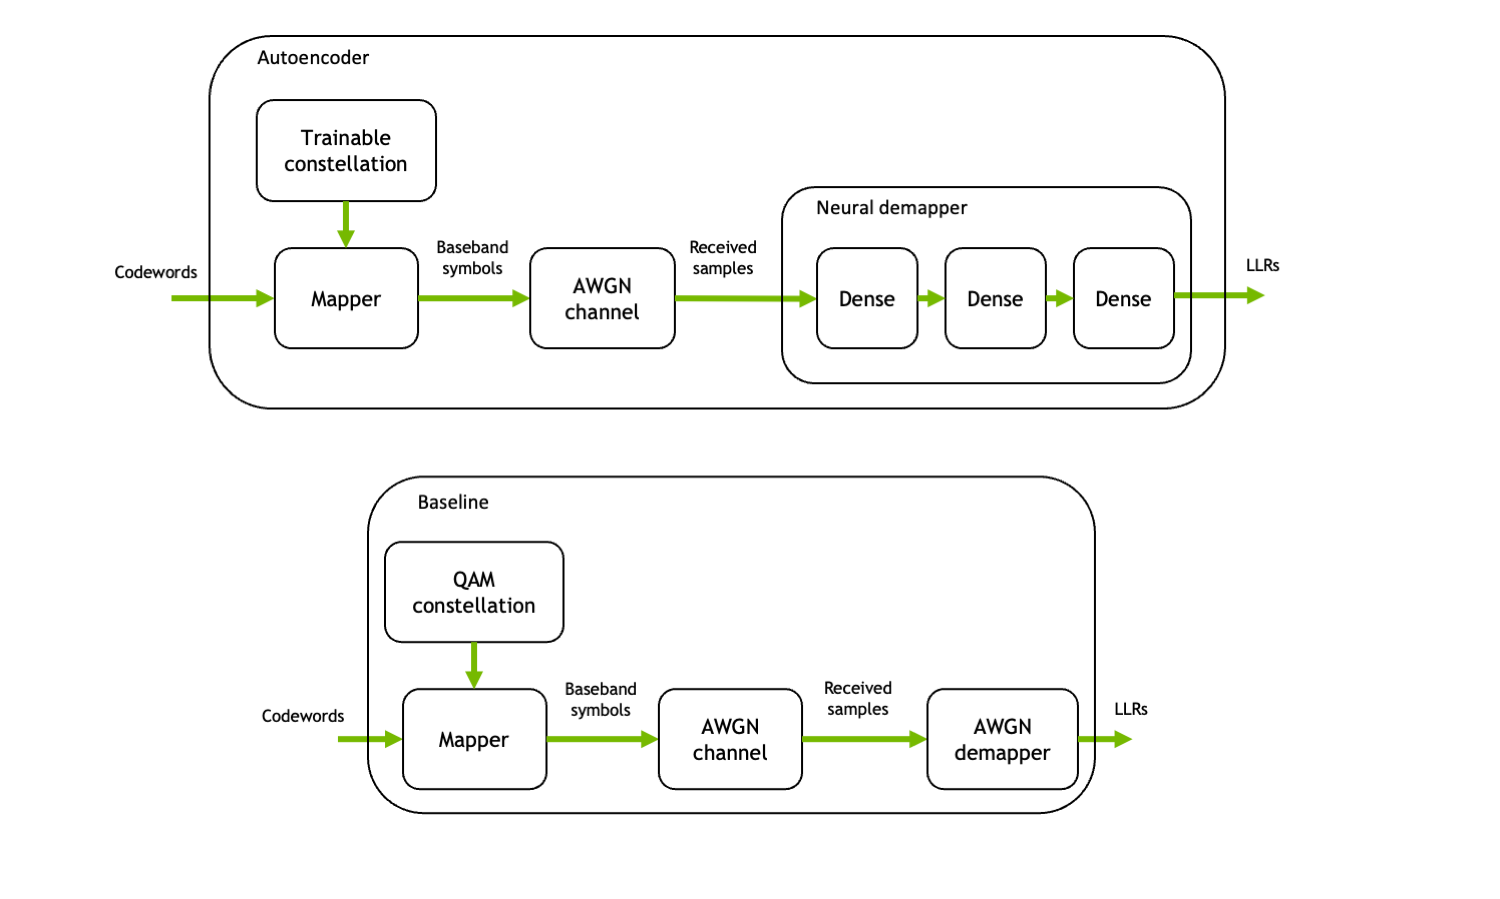


Two algorithms for training the autoencoder are implemented in this notebook:

* Conventional stochastic gradient descent (SGD) with backpropagation, which assumes a differentiable channel model and therefore optimizes the end-to-end system by backpropagating the gradients through the channel (see, e.g., [1]).
* The training algorithm from [3], which does not assume a differentiable channel model, and which trains the end-to-end system by alternating between conventional training of the receiver and reinforcement learning (RL)-based training of the transmitter. Compared to [3], an additional step of fine-tuning of the receiver is performed after alternating training.

**Note:** For an introduction to the implementation of differentiable communication systems and their optimization through SGD and backpropagation with Sionna, please refer to [the Part 2 of the Sionna tutorial for Beginners](https://nvlabs.github.io/sionna/phy/tutorials/notebooks/Sionna_tutorial_part2.html).

* [Configuration and Imports](#Configuration-and-Imports)
* [Simulation Parameters](#Simulation-Parameters)
* [Neural Demapper](#Neural-Demapper)
* [Trainable End-to-end System: Conventional Training](#Trainable-End-to-end-System:-Conventional-Training)
* [Trainable End-to-end System: RL-based Training](#Trainable-End-to-end-System:-RL-based-Training)
* [Evaluation](#Evaluation)
* [Visualizing the Learned Constellations](#Visualizing-the-Learned-Constellations)
* [References](#References)

## Configuration and Imports

In [1]:
# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import os
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

import pickle

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch._dynamo

from sionna.phy import Block
from sionna.phy.channel import AWGN
from sionna.phy.utils import ebnodb2no, expand_to_rank, sim_ber
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, Constellation, BinarySource

sionna.phy.config.seed = 42  # Set seed for reproducible random number generation

%matplotlib inline

## Simulation Parameters

In [2]:
###############################################
# SNR range for evaluation and training [dB]
###############################################
ebno_db_min = 4.0
ebno_db_max = 8.0

###############################################
# Modulation and coding configuration
###############################################
num_bits_per_symbol = 6  # Baseline is 64-QAM
modulation_order = 2**num_bits_per_symbol
coderate = 0.5  # Coderate for the outer code
n = 1500  # Codeword length [bit]. Must be a multiple of num_bits_per_symbol
num_symbols_per_codeword = n // num_bits_per_symbol  # Number of modulated baseband symbols per codeword
k = int(n * coderate)  # Number of information bits per codeword

###############################################
# Training configuration
###############################################
num_training_iterations_conventional = 10000  # Number of training iterations for conventional training
# Number of training iterations with RL-based training for the alternating training phase and fine-tuning of the receiver phase
num_training_iterations_rl_alt = 7000
num_training_iterations_rl_finetuning = 3000
training_batch_size = 128  # Training batch size
rl_perturbation_var = 0.01  # Variance of the perturbation used for RL-based training of the transmitter
model_weights_path_conventional_training = "awgn_autoencoder_weights_conventional_training"  # Filename to save the autoencoder weights once conventional training is done
model_weights_path_rl_training = "awgn_autoencoder_weights_rl_training"  # Filename to save the autoencoder weights once RL-based training is done

###############################################
# Evaluation configuration
###############################################
results_filename = "awgn_autoencoder_results"  # Location to save the results

## Neural Demapper

The neural network-based demapper shown in the figure above is made of three dense layers with ReLU activation.

The input of the demapper consists of a received sample $y \in \mathbb{C}$ and the noise power spectral density $N_0$ in log-10 scale to handle different orders of magnitude for the SNR.

As the neural network can only process real-valued inputs, these values are fed as a 3-dimensional vector

$$\left[ \mathcal{R}(y), \mathcal{I}(y), \log_{10}(N_0) \right]$$

where $\mathcal{R}(y)$ and $\mathcal{I}(y)$ refer to the real and imaginary component of $y$, respectively.

The output of the neural network-based demapper consists of LLRs on the `num_bits_per_symbol` bits mapped to a constellation point. Therefore, the last layer consists of ``num_bits_per_symbol`` units.

**Note**: The neural network-based demapper processes the received samples $y$ forming a block individually. The [neural receiver notebook](https://nvlabs.github.io/sionna/phy/tutorials/notebooks/Neural_Receiver.html) provides an example of a more advanced neural network-based receiver that jointly processes a resource grid of received symbols.

In [3]:
class NeuralDemapper(nn.Module):
    """Neural network-based demapper with three dense layers and ReLU activation.
    
    The input of the demapper consists of a received sample y ∈ ℂ and the noise
    variance. The output is a vector of LLRs for each bit carried by a symbol.
    """

    def __init__(self):
        super().__init__()
        
        self._dense_1 = nn.Linear(3, 128)
        self._dense_2 = nn.Linear(128, 128)
        self._dense_3 = nn.Linear(128, num_bits_per_symbol)  # Output LLRs for every bit

    def forward(self, y, no):
        # Using log10 scale helps with the performance
        no_db = torch.log10(no)
        
        # Stacking the real and imaginary components of the complex received samples
        # and the noise variance
        no_db = no_db.expand(-1, num_symbols_per_codeword)  # [batch size, num_symbols_per_codeword]
        z = torch.stack([y.real, y.imag, no_db], dim=2)  # [batch size, num_symbols_per_codeword, 3]
        
        llr = F.relu(self._dense_1(z))
        llr = F.relu(self._dense_2(llr))
        llr = self._dense_3(llr)  # [batch size, num_symbols_per_codeword, num_bits_per_symbol]
        
        return llr

## Trainable End-to-end System: Conventional Training

The following cell defines an end-to-end communication system that transmits bits modulated using a trainable constellation over an AWGN channel.

The receiver uses the previously defined neural network-based demapper to compute LLRs on the transmitted (coded) bits.

As in [1], the constellation and neural network-based demapper are jointly trained through SGD and backpropagation using the binary cross entropy (BCE) as loss function.

Training on the BCE is known to be equivalent to maximizing an achievable information rate [2].

The following model can be instantiated either for training (`training = True`) or evaluation (`training = False`).

In the former case, the BCE is returned and no outer code is used to reduce computational complexity and as it does not impact the training of the constellation or demapper.

When setting `training` to `False`, an LDPC outer code from 5G NR is applied.

In [4]:
class E2ESystemConventionalTraining(nn.Module):
    """End-to-end communication system for conventional training.
    
    This system transmits bits modulated using a trainable constellation over
    an AWGN channel. The receiver uses a neural network-based demapper.
    """

    def __init__(self, training):
        super().__init__()
        
        self._training = training
        
        ################
        ## Transmitter
        ################
        self._binary_source = BinarySource()
        # To reduce the computational complexity of training, the outer code is not used when training
        if not self._training:
            # num_bits_per_symbol is required for the interleaver
            self._encoder = LDPC5GEncoder(k, n, num_bits_per_symbol)
        
        # Trainable constellation
        # We initialize a custom constellation with QAM points
        qam_points = Constellation("qam", num_bits_per_symbol).points
        self.points_r = nn.Parameter(qam_points.real.clone())
        self.points_i = nn.Parameter(qam_points.imag.clone())

        self.constellation = Constellation("custom",
                                           num_bits_per_symbol,
                                           points=torch.complex(self.points_r, self.points_i),
                                           normalize=True,
                                           center=True)
       
        
        self._mapper = Mapper(constellation=self.constellation)
        
        ################
        ## Channel
        ################
        self._channel = AWGN()
        
        ################
        ## Receiver
        ################
        # We use the previously defined neural network for demapping
        self._demapper = NeuralDemapper()
        # To reduce the computational complexity of training, the outer code is not used when training
        if not self._training:
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def forward(self, batch_size, ebno_db):
        
        # Update constellation points from trainable parameters (creates fresh graph)
        self.constellation.points = torch.complex(self.points_r, self.points_i)

        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        no = expand_to_rank(no, 2)
        
        ################
        ## Transmitter
        ################
        # Outer coding is only performed if not training
        if self._training:
            c = self._binary_source([batch_size, n])
        else:
            b = self._binary_source([batch_size, k])
            c = self._encoder(b)
        # Modulation
        x = self._mapper(c)  # x [batch size, num_symbols_per_codeword]
        
        ################
        ## Channel
        ################
        y = self._channel(x, no)  # [batch size, num_symbols_per_codeword]
        
        ################
        ## Receiver
        ################
        llr = self._demapper(y, no)
        llr = llr.reshape(batch_size, n)
        # If training, outer decoding is not performed and the BCE is returned
        if self._training:
            loss = F.binary_cross_entropy_with_logits(llr, c)
            return loss
        else:
            # Outer decoding
            b_hat = self._decoder(llr)
            return b, b_hat  # Ground truth and reconstructed information bits returned for BER/BLER computation

A simple training loop is defined in the next cell, which performs `num_training_iterations_conventional` training iterations of SGD. Training is done over a range of SNR, by randomly sampling a batch of SNR values at each iteration.

**Note:** For an introduction to the implementation of differentiable communication systems and their optimization through SGD and backpropagation with Sionna, please refer to [the Part 2 of the Sionna tutorial for Beginners](https://nvlabs.github.io/sionna/phy/tutorials/notebooks/Sionna_tutorial_part2.html).

In [5]:
def conventional_training(model):
    """Train the model using conventional SGD with backpropagation."""
    # Optimizer used to apply gradients
    optimizer = torch.optim.Adam(model.parameters())
    device = sionna.phy.config.device
    
    for i in range(num_training_iterations_conventional):
        optimizer.zero_grad()
        # Sampling a batch of SNRs
        ebno_db = torch.empty(training_batch_size, device=device).uniform_(ebno_db_min, ebno_db_max)
        # Forward pass
        loss = model(training_batch_size, ebno_db)
        # Computing and applying gradients
        loss.backward()
        optimizer.step()
        # Printing periodically the progress
        if i % 100 == 0:
            print(f'Iteration {i}/{num_training_iterations_conventional}  BCE: {loss.item():.4f}', end='\r')
    print()
    model.eval()
    optimizer.zero_grad(set_to_none=True)

The next cell defines a utility function for saving the weights using [pickle](https://docs.python.org/3/library/pickle.html).

In [6]:
def save_weights(model, model_weights_path):
    """Save model weights using torch.save."""
    torch.save(model._orig_mod.state_dict(), model_weights_path)

In the next cell, an instance of the model defined previously is instantiated and trained.

In [7]:
# Instantiate and train the end-to-end system
device = sionna.phy.config.device
model = torch.compile(E2ESystemConventionalTraining(training=True).to(device), mode="reduce-overhead")
conventional_training(model)
save_weights(model, model_weights_path_conventional_training)

Iteration 0/10000  BCE: 0.6895
Iteration 200/10000  BCE: 0.3131
Iteration 400/10000  BCE: 0.3018
Iteration 600/10000  BCE: 0.2977
Iteration 800/10000  BCE: 0.2866
Iteration 1000/10000  BCE: 0.2912
Iteration 1200/10000  BCE: 0.2883
Iteration 1400/10000  BCE: 0.2916
Iteration 1600/10000  BCE: 0.2913
Iteration 1800/10000  BCE: 0.2848
Iteration 2000/10000  BCE: 0.2940
Iteration 2200/10000  BCE: 0.2842
Iteration 2400/10000  BCE: 0.2842
Iteration 2600/10000  BCE: 0.2883
Iteration 2800/10000  BCE: 0.2887
Iteration 3000/10000  BCE: 0.2886
Iteration 3200/10000  BCE: 0.2835
Iteration 3400/10000  BCE: 0.2820
Iteration 3600/10000  BCE: 0.2819
Iteration 3800/10000  BCE: 0.2879
Iteration 4000/10000  BCE: 0.2924
Iteration 4200/10000  BCE: 0.2925
Iteration 4400/10000  BCE: 0.2839
Iteration 4600/10000  BCE: 0.2866
Iteration 4800/10000  BCE: 0.2897
Iteration 5000/10000  BCE: 0.2818
Iteration 5200/10000  BCE: 0.2890
Iteration 5400/10000  BCE: 0.2833
Iteration 5600/10000  BCE: 0.2905
Iteration 5800/10000 

## Trainable End-to-end System: RL-based Training

The following cell defines the same end-to-end system as before, but stop the gradients after the channel to simulate a non-differentiable channel.

To jointly train the transmitter and receiver over a non-differentiable channel, we follow [3], which key idea is to alternate between:

- Training of the receiver on the BCE using conventional backpropagation and SGD.
- Training of the transmitter by applying (known) perturbations to the transmitter output to enable estimation of the gradient of the transmitter weights with respect to an approximation of the loss function.

When `training` is set to `True`, both losses for training the receiver and the transmitter are returned.

In [8]:
class E2ESystemRLTraining(nn.Module):
    """End-to-end communication system for RL-based training.
    
    This system is similar to E2ESystemConventionalTraining but stops gradients
    after the channel to simulate a non-differentiable channel. Training uses
    reinforcement learning with perturbation-based exploration.
    """

    def __init__(self, training):
        super().__init__()
        
        self._training = training
        
        ################
        ## Transmitter
        ################
        self._binary_source = BinarySource()
        # To reduce the computational complexity of training, the outer code is not used when training
        if not self._training:
            self._encoder = LDPC5GEncoder(k, n, num_bits_per_symbol)
        
        # Trainable constellation
        # We initialize a custom constellation with QAM points
        qam_points = Constellation("qam", num_bits_per_symbol).points
        self.points_r = nn.Parameter(qam_points.real.clone())
        self.points_i = nn.Parameter(qam_points.imag.clone())

        self.constellation = Constellation("custom",
                                           num_bits_per_symbol,
                                           points=torch.complex(self.points_r, self.points_i),
                                           normalize=True,
                                           center=True)
        
        self._mapper = Mapper(constellation=self.constellation)
        
        ################
        ## Channel
        ################
        self._channel = AWGN()
        
        ################
        ## Receiver
        ################
        # We use the previously defined neural network for demapping
        self._demapper = NeuralDemapper()
        # To reduce the computational complexity of training, the outer code is not used when training
        if not self._training:
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def forward(self, batch_size, ebno_db, perturbation_variance=0.0):
        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        no = expand_to_rank(no, 2)
        
        ################
        ## Transmitter
        ################
        # Outer coding is only performed if not training
        if self._training:
            c = self._binary_source([batch_size, n])
        else:
            b = self._binary_source([batch_size, k])
            c = self._encoder(b)
        # Modulation
        # Update constellation points from trainable parameters
        self.constellation.points = torch.complex(self.points_r, self.points_i)
        x = self._mapper(c)  # x [batch size, num_symbols_per_codeword]
        
        # Adding perturbation
        # If ``perturbation_variance`` is 0, then the added perturbation is null
        std = (0.5 * perturbation_variance) ** 0.5
        epsilon_r = torch.randn(x.shape, device=x.device, dtype=x.real.dtype) * std
        epsilon_i = torch.randn(x.shape, device=x.device, dtype=x.real.dtype) * std
        epsilon = torch.complex(epsilon_r, epsilon_i)  # [batch size, num_symbols_per_codeword]
        x_p = x + epsilon  # [batch size, num_symbols_per_codeword]
        
        ################
        ## Channel
        ################
        y = self._channel(x_p, no)  # [batch size, num_symbols_per_codeword]
        y = y.detach()  # Stop gradient here
        
        ################
        ## Receiver
        ################
        llr = self._demapper(y, no)
        
        # If training, outer decoding is not performed
        if self._training:
            # Average BCE for each baseband symbol and each batch example
            c_reshaped = c.reshape(-1, num_symbols_per_codeword, num_bits_per_symbol)
            bce = F.binary_cross_entropy_with_logits(llr, c_reshaped, reduction='none').mean(dim=2)  # Average over the bits mapped to a same baseband symbol
            # The RX loss is the usual average BCE
            rx_loss = bce.mean()
            # From the TX side, the BCE is seen as a feedback from the RX through which backpropagation is not possible
            bce = bce.detach()  # [batch size, num_symbols_per_codeword]
            x_p = x_p.detach()
            p = x_p - x  # [batch size, num_symbols_per_codeword] Gradient is backpropagated through `x`
            tx_loss = p.real.square() + p.imag.square()  # [batch size, num_symbols_per_codeword]
            tx_loss = -bce * tx_loss / rl_perturbation_var  # [batch size, num_symbols_per_codeword]
            tx_loss = tx_loss.mean()
            return tx_loss, rx_loss
        else:
            llr = llr.reshape(-1, n)  # Reshape as expected by the outer decoder
            b_hat = self._decoder(llr)
            return b, b_hat

The next cell implements the training algorithm from [3], which alternates between conventional training of the neural network-based receiver, and RL-based training of the transmitter.

In [9]:
def rl_based_training(model):
    """Train the model using RL-based training algorithm."""
    # Optimizers used to apply gradients
    optimizer_tx = torch.optim.Adam(model.parameters())  # For training the transmitter
    optimizer_rx = torch.optim.Adam(model.parameters())  # For training the receiver
    device = sionna.phy.config.device
    
    # Training loop
    for i in range(num_training_iterations_rl_alt):
        # 10 steps of receiver training are performed to keep it ahead of the transmitter
        # as it is used for computing the losses when training the transmitter
        for _ in range(10):
            optimizer_rx.zero_grad()
            # Sampling a batch of SNRs
            ebno_db = torch.empty(training_batch_size, device=device).uniform_(ebno_db_min, ebno_db_max)
            # Forward pass - keep only the RX loss, no perturbation
            _, rx_loss = model(training_batch_size, ebno_db)
            rx_loss.backward()
            optimizer_rx.step()
        # One step of transmitter training
        optimizer_tx.zero_grad()
        # Sampling a batch of SNRs
        ebno_db = torch.empty(training_batch_size, device=device).uniform_(ebno_db_min, ebno_db_max)
        # Forward pass - keep only the TX loss, perturbations added for RL exploration
        tx_loss, _ = model(training_batch_size, ebno_db, rl_perturbation_var)
        tx_loss.backward()
        optimizer_tx.step()
        # Printing periodically the progress
        if i % 100 == 0:
            print(f'Iteration {i}/{num_training_iterations_rl_alt}  BCE {rx_loss.item():.4f}', end='\r')
    print()  # Line break
    
    # Once alternating training is done, the receiver is fine-tuned
    print('Receiver fine-tuning... ')
    for i in range(num_training_iterations_rl_finetuning):
        optimizer_rx.zero_grad()
        ebno_db = torch.empty(training_batch_size, device=device).uniform_(ebno_db_min, ebno_db_max)
        _, rx_loss = model(training_batch_size, ebno_db)
        rx_loss.backward()
        optimizer_rx.step()
        if i % 100 == 0:
            print(f'Iteration {i}/{num_training_iterations_rl_finetuning}  BCE {rx_loss.item():.4f}', end='\r')
    print()
    model.eval()
    optimizer_tx.zero_grad(set_to_none=True)
    optimizer_rx.zero_grad(set_to_none=True)

In the next cell, an instance of the model defined previously is instantiated and trained.

In [10]:
# Instantiate and train the end-to-end system
model = torch.compile(E2ESystemRLTraining(training=True).to(device), mode="reduce-overhead")
rl_based_training(model)
save_weights(model, model_weights_path_rl_training)

Iteration 6900/7000  BCE 0.3030
Receiver fine-tuning... 
Iteration 0/3000  BCE 0.2799
Iteration 200/3000  BCE 0.2800
Iteration 400/3000  BCE 0.2843
Iteration 600/3000  BCE 0.2827
Iteration 800/3000  BCE 0.2819
Iteration 1000/3000  BCE 0.2846
Iteration 1200/3000  BCE 0.2830
Iteration 1400/3000  BCE 0.2883
Iteration 1600/3000  BCE 0.2873
Iteration 1800/3000  BCE 0.2815
Iteration 2000/3000  BCE 0.2886
Iteration 2100/3000  BCE 0.2821
Iteration 2300/3000  BCE 0.2895
Iteration 2400/3000  BCE 0.2765
Iteration 2600/3000  BCE 0.2890
Iteration 2700/3000  BCE 0.2875
Iteration 2900/3000  BCE 0.2878


## Evaluation

The following cell implements a baseline which uses QAM with Gray labeling and conventional demapping for AWGN channel.

In [11]:
class Baseline(nn.Module):
    """Baseline system using QAM with Gray labeling and conventional demapping."""

    def __init__(self):
        super().__init__()
        
        ################
        ## Transmitter
        ################
        self._binary_source = BinarySource()
        self._encoder = LDPC5GEncoder(k, n, num_bits_per_symbol)
        constellation = Constellation("qam", num_bits_per_symbol)
        self.constellation = constellation
        self._mapper = Mapper(constellation=constellation)
        
        ################
        ## Channel
        ################
        self._channel = AWGN()
        
        ################
        ## Receiver
        ################
        self._demapper = Demapper("app", constellation=constellation)
        self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def forward(self, batch_size, ebno_db):
        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        no = expand_to_rank(no, 2)
        
        ################
        ## Transmitter
        ################
        b = self._binary_source([batch_size, k])
        c = self._encoder(b)
        # Modulation
        x = self._mapper(c)  # x [batch size, num_symbols_per_codeword]
        
        ################
        ## Channel
        ################
        y = self._channel(x, no)  # [batch size, num_symbols_per_codeword]
        
        ################
        ## Receiver
        ################
        llr = self._demapper(y, no)
        # Outer decoding
        b_hat = self._decoder(llr)
        return b, b_hat  # Ground truth and reconstructed information bits returned for BER/BLER computation

In [12]:
# Range of SNRs over which the systems are evaluated
ebno_dbs = np.arange(ebno_db_min,  # Min SNR for evaluation
                     ebno_db_max,  # Max SNR for evaluation
                     0.5)  # Step

In [13]:
# Utility function to load and set weights of a model
def load_weights(model, model_weights_path):
    """Load and set weights of a model."""
    device = sionna.phy.config.device
    state = torch.load(model_weights_path, map_location=device)
    model.load_state_dict(state, strict=False)
    # Update the constellation points from the loaded parameters
    model.constellation.points = torch.complex(model.points_r, model.points_i)

The next cell evaluate the baseline and the two autoencoder-based communication systems, trained with different method.
The results are stored in the dictionary ``BLER``.

In [14]:
torch._dynamo.reset()
torch.cuda.empty_cache() 

# Dictionary storing the results
BLER = {}

with torch.no_grad():  

    model_baseline = Baseline().to(device)
    _, bler = sim_ber(model_baseline, ebno_dbs, batch_size=128, num_target_block_errors=1000, max_mc_iter=1000, compile_mode="reduce-overhead")
    BLER['baseline'] = bler.cpu().numpy()

    model_conventional = E2ESystemConventionalTraining(training=False).to(device)
    load_weights(model_conventional, model_weights_path_conventional_training)
    _, bler = sim_ber(model_conventional, ebno_dbs, batch_size=128, num_target_block_errors=1000, max_mc_iter=1000, compile_mode="reduce-overhead")
    BLER['autoencoder-conv'] = bler.cpu().numpy()

    model_rl = E2ESystemRLTraining(training=False).to(device)
    load_weights(model_rl, model_weights_path_rl_training)
    _, bler = sim_ber(model_rl, ebno_dbs, batch_size=128, num_target_block_errors=1000, max_mc_iter=1000, compile_mode="reduce-overhead")
    BLER['autoencoder-rl'] = bler.cpu().numpy()

with open(results_filename, 'wb') as f:
    pickle.dump((ebno_dbs, BLER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      4.0 | 1.2266e-01 | 1.0000e+00 |       94202 |      768000 |         1024 |        1024 |        12.9 |reached target block errors
      4.5 | 9.6753e-02 | 9.9805e-01 |       74306 |      768000 |         1022 |        1024 |         0.0 |reached target block errors
      5.0 | 5.9906e-02 | 9.1580e-01 |       51759 |      864000 |         1055 |        1152 |         0.0 |reached target block errors
      5.5 | 1.9831e-02 | 5.1904e-01 |       30461 |     1536000 |         1063 |        2048 |         0.0 |reached target block errors
      6.0 | 2.6508e-03 | 1.1707e-01 |       17050 |     6432000 |         1004 |        8576 |         0.2 |reached target block errors
      6.5 | 1.1691e-04 | 9.2785e-03 |        9450 |    80832000 |

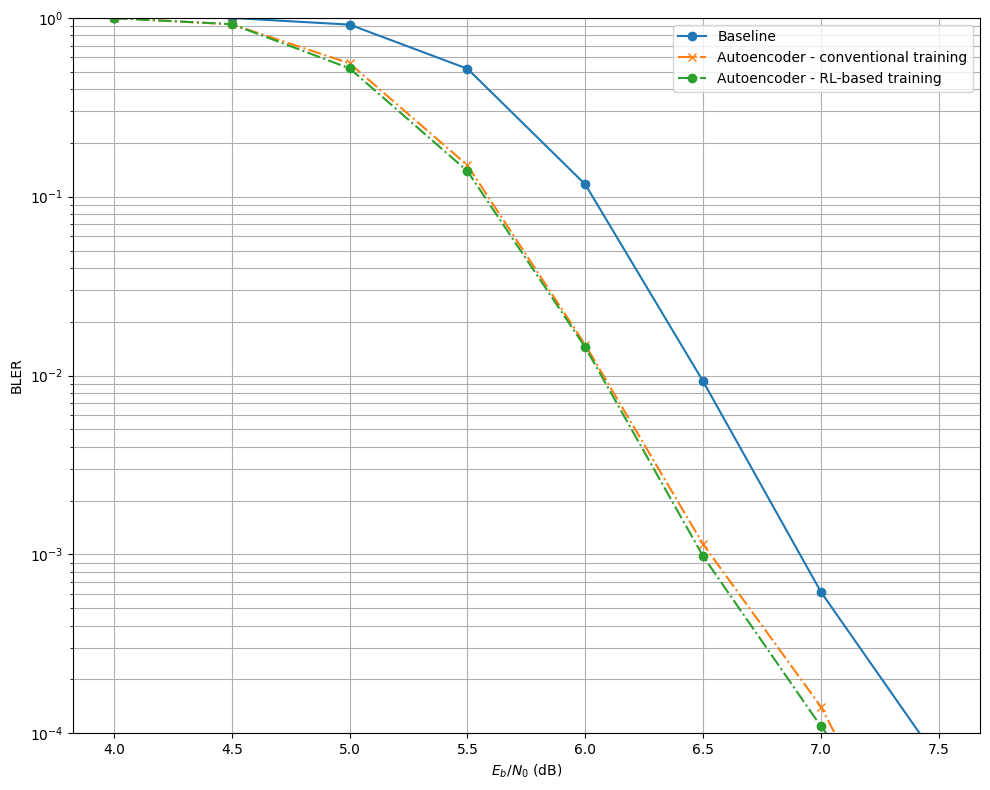

In [15]:
plt.figure(figsize=(10, 8))
# Baseline - Perfect CSI
plt.semilogy(ebno_dbs, BLER['baseline'], 'o-', c='C0', label='Baseline')
# Autoencoder - conventional training
plt.semilogy(ebno_dbs, BLER['autoencoder-conv'], 'x-.', c='C1', label='Autoencoder - conventional training')
# Autoencoder - RL-based training
plt.semilogy(ebno_dbs, BLER['autoencoder-rl'], 'o-.', c='C2', label='Autoencoder - RL-based training')

plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BLER")
plt.grid(which="both")
plt.ylim((1e-4, 1.0))
plt.legend()
plt.tight_layout()

## Visualizing the Learned Constellations

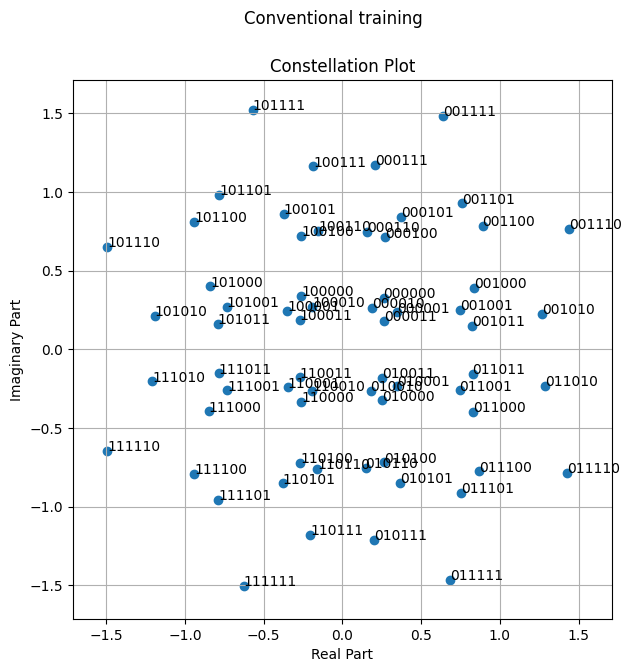

In [16]:
model_conventional = E2ESystemConventionalTraining(training=True).to(device)
load_weights(model_conventional, model_weights_path_conventional_training)
model_conventional.constellation.points = torch.complex(model_conventional.points_r, model_conventional.points_i)
fig = model_conventional.constellation.show()
fig.suptitle('Conventional training');

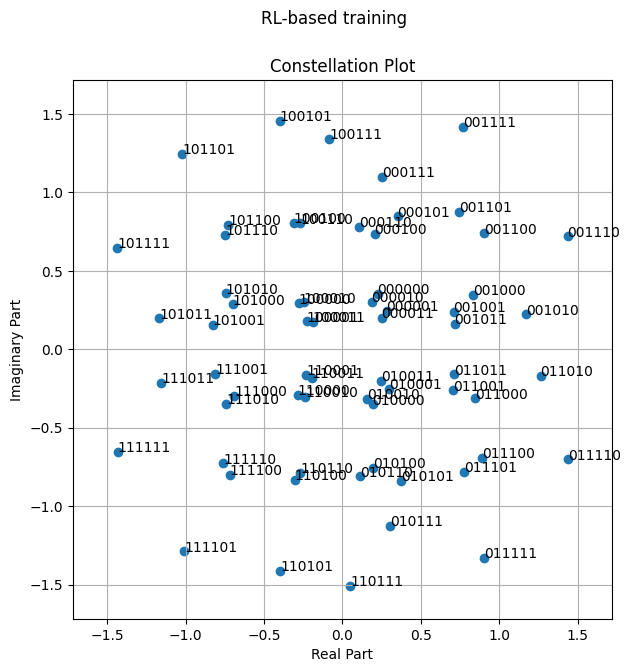

In [17]:
model_rl = E2ESystemRLTraining(training=False).to(device)
load_weights(model_rl, model_weights_path_rl_training)
model_rl.constellation.points = torch.complex(model_rl.points_r, model_rl.points_i)
fig = model_rl.constellation.show()
fig.suptitle('RL-based training');

## References

[1] T. O’Shea and J. Hoydis, "An Introduction to Deep Learning for the Physical Layer," in IEEE Transactions on Cognitive Communications and Networking, vol. 3, no. 4, pp. 563-575, Dec. 2017, doi: 10.1109/TCCN.2017.2758370.

[2] S. Cammerer, F. Ait Aoudia, S. Dörner, M. Stark, J. Hoydis and S. ten Brink, "Trainable Communication Systems: Concepts and Prototype," in IEEE Transactions on Communications, vol. 68, no. 9, pp. 5489-5503, Sept. 2020, doi: 10.1109/TCOMM.2020.3002915.

[3] F. Ait Aoudia and J. Hoydis, "Model-Free Training of End-to-End Communication Systems," in IEEE Journal on Selected Areas in Communications, vol. 37, no. 11, pp. 2503-2516, Nov. 2019, doi: 10.1109/JSAC.2019.2933891.